# Retail Store Sales Insights and Demand Prediction System

## Project Introduction

**Objective:** analyse retail sales data, identify what is associated with higher sales, and build a model that predicts sales for an item sold at an outlet.

**Dataset:** `data.csv` – one row per *item × outlet* combination (item attributes, outlet attributes and the total sales of that item at that outlet).

### What the dataset does and does not support
I inspected the file before designing this notebook. Its columns are:

`Item_Identifier, Item_Weight, Item_Fat_Content, Item_Visibility, Item_Type, Item_MRP, Outlet_Identifier, Outlet_Establishment_Year, Outlet_Size, Outlet_Location_Type, Outlet_Type, Item_Outlet_Sales`



## Import Libraries

In [53]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.labelsize": 11})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## Load Dataset



In [54]:
FILE = "data.csv"
if not os.path.exists(FILE):
    try:
        from google.colab import files
        print("Please upload data.csv")
        uploaded = files.upload()
        FILE = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("data.csv not found. Place it next to this notebook.")

raw = pd.read_csv(FILE)
print(f"Loaded '{FILE}' with {raw.shape[0]:,} rows and {raw.shape[1]} columns")
raw.head()

Loaded 'data.csv' with 14,204 rows and 12 columns


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016,Dairy,249.809,OUT049,1999,Medium,Tier 1,Supermarket Type1,"3,735.138"
1,DRC01,5.920,Regular,0.019,Soft Drinks,48.269,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.423
2,FDN15,17.500,Low Fat,0.017,Meat,141.618,OUT049,1999,Medium,Tier 1,Supermarket Type1,"2,097.270"
3,FDX07,19.200,Regular,0.000,Fruits and Vegetables,182.095,OUT010,1998,NaN,Tier 3,Grocery Store,732.380
4,NCD19,8.930,Low Fat,0.000,Household,53.861,OUT013,1987,High,Tier 3,Supermarket Type1,994.705


## 4. Data Inspection

In [55]:
print("Shape:", raw.shape)
print("\nData types:")
print(raw.dtypes.to_string())

print("\nNumeric summary:")
display(raw.describe().T)

print("\nCategorical summary:")
cat_raw = [c for c in raw.columns if not pd.api.types.is_numeric_dtype(raw[c])]
display(raw[cat_raw].describe().T)

Shape: (14204, 12)

Data types:
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
Item_Weight,"11,765.000",12.793,4.653,4.555,8.710,12.600,16.750,21.350
Item_Visibility,"14,204.000",0.066,0.051,0.000,0.027,0.054,0.094,0.328
Item_MRP,"14,204.000",141.005,62.087,31.290,94.012,142.247,185.856,266.888
Outlet_Establishment_Year,"14,204.000","1,997.831",8.372,"1,985.000","1,987.000","1,999.000","2,004.000","2,009.000"
Item_Outlet_Sales,"14,204.000","2,099.334","1,542.433",33.290,878.856,"1,828.273","2,949.298","13,086.965"



Categorical summary:


,count,unique,top,freq
Item_Identifier,14204,1559,FDX13,10
Item_Fat_Content,14204,5,Low Fat,8485
Item_Type,14204,16,Fruits and Vegetables,2013
Outlet_Identifier,14204,10,OUT027,1559
Outlet_Size,10188,3,Medium,4655
Outlet_Location_Type,14204,3,Tier 3,5583
Outlet_Type,14204,4,Supermarket Type1,9294


In [56]:

miss = raw.isna().sum().to_frame("missing")
miss["pct_missing"] = (miss["missing"] / len(raw) * 100).round(2)
print("Missing values per column:")
display(miss[miss["missing"] > 0])

print("\nOutlets where Item_Weight is missing:")
print(raw.loc[raw["Item_Weight"].isna(), "Outlet_Identifier"].value_counts().to_string())
print("\nShare of Outlet_Size missing, by outlet (1.0 = missing for every row of that outlet):")
print(raw.groupby("Outlet_Identifier")["Outlet_Size"].apply(lambda s: s.isna().mean()).round(2).to_string())

Missing values per column:


,missing,pct_missing
Item_Weight,2439,17.170
Outlet_Size,4016,28.270



Outlets where Item_Weight is missing:
Outlet_Identifier
OUT027    1559
OUT019     880

Share of Outlet_Size missing, by outlet (1.0 = missing for every row of that outlet):
Outlet_Identifier
OUT010   1.000
OUT013   0.000
OUT017   1.000
OUT018   0.000
OUT019   0.000
OUT027   0.000
OUT035   0.000
OUT045   1.000
OUT046   0.000
OUT049   0.000


In [57]:

print("Fully duplicated rows:", raw.duplicated().sum())
print("Duplicated (Item_Identifier, Outlet_Identifier) pairs:", raw.duplicated(["Item_Identifier", "Outlet_Identifier"]).sum())


print("\nItem_Fat_Content labels (note inconsistent spellings):")
print(raw["Item_Fat_Content"].value_counts().to_string())

print("\nRows with Item_Visibility == 0 (an item on sale cannot have zero display area):",
      (raw["Item_Visibility"] == 0).sum())
print("Rows with Item_MRP <= 0       :", (raw["Item_MRP"] <= 0).sum())
print("Rows with Item_Outlet_Sales <= 0:", (raw["Item_Outlet_Sales"] <= 0).sum())
print("Rows with Item_Weight <= 0    :", (raw["Item_Weight"] <= 0).sum())
print("Establishment year range      :", raw["Outlet_Establishment_Year"].min(), "-", raw["Outlet_Establishment_Year"].max())

print("\nMax distinct values of each outlet attribute within one outlet (should be 1):")
print(raw.groupby("Outlet_Identifier")[["Outlet_Establishment_Year", "Outlet_Location_Type", "Outlet_Type"]].nunique().max().to_string())
print("Max distinct Item_Weight values within one item (should be 1):",
      raw.groupby("Item_Identifier")["Item_Weight"].nunique().max())
print("Items whose weight is missing in EVERY row:",
      int(raw.groupby("Item_Identifier")["Item_Weight"].apply(lambda s: s.isna().all()).sum()))

Fully duplicated rows: 0
Duplicated (Item_Identifier, Outlet_Identifier) pairs: 0

Item_Fat_Content labels (note inconsistent spellings):
Item_Fat_Content
Low Fat    8485
Regular    4824
LF          522
reg         195
low fat     178

Rows with Item_Visibility == 0 (an item on sale cannot have zero display area): 879
Rows with Item_MRP <= 0       : 0
Rows with Item_Outlet_Sales <= 0: 0
Rows with Item_Weight <= 0    : 0
Establishment year range      : 1985 - 2009

Max distinct values of each outlet attribute within one outlet (should be 1):
Outlet_Establishment_Year    1
Outlet_Location_Type         1
Outlet_Type                  1
Max distinct Item_Weight values within one item (should be 1): 1
Items whose weight is missing in EVERY row: 0


## 5. Data Cleaning

Decisions (each is applied programmatically below). **None of the imputations uses the target (`Item_Outlet_Sales`)**, so they cannot leak target information into the models.

1. **Item_Fat_Content** – `LF`, `low fat`, `reg` are spelling variants of `Low Fat` / `Regular`; they are standardised. Items whose ID starts with `NC` (non-consumables) cannot have a fat content, so they are labelled `Non-Edible`.
2. **Item_Weight (missing)** – weight is a fixed property of an item (verified above), so a missing weight is filled from the same item's weight in other outlets. Fallback: median weight of the item type.
3. **Outlet_Size (missing)** – missing for whole outlets, not random rows. It is imputed from the most common size among *other outlets* with the same `Outlet_Type` and `Outlet_Location_Type` (fallback: same `Outlet_Type`). This is an assumption, so the imputed outlets are flagged with `Outlet_Size_Imputed`.
4. **Item_Visibility = 0** – treated as a missing value (not a real measurement) and replaced by the item's mean non-zero visibility in other rows. Flagged with `Visibility_Zero_Flag`.
5. **Dates** – the dataset has no date column; the notebook checks this and reports it instead of inventing one.
6. **Outliers** – checked with the IQR rule and **kept**: the high sales values are plausible for high-MRP items and are the cases the model should learn from. Tree models are insensitive to them; the effect on Linear Regression is discussed with the results.
7. **Duplicates** – none found (checked above), so no rows are dropped.

In [58]:
df = raw.copy()

text_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
for c in text_cols:
    df[c] = df[c].str.strip()

fat_map = {"low fat": "Low Fat", "lf": "Low Fat", "regular": "Regular", "reg": "Regular"}
df["Item_Fat_Content"] = df["Item_Fat_Content"].str.lower().map(fat_map)
assert df["Item_Fat_Content"].notna().all(), "Unmapped fat-content label found"

df["Item_Category"] = df["Item_Identifier"].str[:2].map({"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"})
assert df["Item_Category"].notna().all(), "Unexpected Item_Identifier prefix"
df.loc[df["Item_Category"] == "Non-Consumable", "Item_Fat_Content"] = "Non-Edible"


df["Item_Weight_Imputed"] = df["Item_Weight"].isna()
item_weight = df.groupby("Item_Identifier")["Item_Weight"].mean()
df["Item_Weight"] = df["Item_Weight"].fillna(df["Item_Identifier"].map(item_weight))
df["Item_Weight"] = df["Item_Weight"].fillna(df.groupby("Item_Type")["Item_Weight"].transform("median"))

outlets = df.groupby("Outlet_Identifier")[["Outlet_Type", "Outlet_Location_Type", "Outlet_Size"]].first()
known = outlets.dropna(subset=["Outlet_Size"])

def impute_size(row):
    pool = known[(known["Outlet_Type"] == row["Outlet_Type"]) &
                 (known["Outlet_Location_Type"] == row["Outlet_Location_Type"])]["Outlet_Size"]
    if pool.empty:
        pool = known[known["Outlet_Type"] == row["Outlet_Type"]]["Outlet_Size"]
    if pool.empty:
        pool = known["Outlet_Size"]
    return pool.mode().iloc[0]

missing_outlets = outlets[outlets["Outlet_Size"].isna()]
size_fill = {oid: impute_size(r) for oid, r in missing_outlets.iterrows()}
print("Outlet_Size imputation (assumption-based):", size_fill)

df["Outlet_Size_Imputed"] = df["Outlet_Size"].isna()
df["Outlet_Size"] = df["Outlet_Size"].fillna(df["Outlet_Identifier"].map(size_fill))

df["Visibility_Zero_Flag"] = df["Item_Visibility"] == 0
vis_nonzero = df["Item_Visibility"].where(df["Item_Visibility"] > 0)
item_vis_mean = vis_nonzero.groupby(df["Item_Identifier"]).transform("mean")
df["Item_Visibility"] = np.where(df["Visibility_Zero_Flag"], item_vis_mean, df["Item_Visibility"])
df["Item_Visibility"] = df["Item_Visibility"].fillna(vis_nonzero.median())

date_like = [c for c in df.columns
             if any(k in c.lower() for k in ("date", "time", "day", "month"))
             or pd.api.types.is_datetime64_any_dtype(df[c])]
if date_like:
    for c in date_like:
        df[c] = pd.to_datetime(df[c], errors="coerce")
    print("Converted date columns:", date_like)
else:
    print("No date/time column exists in this dataset -> no date conversion is possible, "
          "and time-based trend/forecast analysis will not be fabricated.")

core_cols = raw.columns
print("\nRemaining missing values in original columns:", int(df[core_cols].isna().sum().sum()))
print("Cleaned shape:", df.shape)
for c in ["Item_Fat_Content", "Outlet_Size", "Item_Category"]:
    print(f"\n{c}:\n{df[c].value_counts().to_string()}")

Outlet_Size imputation (assumption-based): {'OUT010': 'Small', 'OUT017': 'Small', 'OUT045': 'Small'}
No date/time column exists in this dataset -> no date conversion is possible, and time-based trend/forecast analysis will not be fabricated.

Remaining missing values in original columns: 0
Cleaned shape: (14204, 16)

Item_Fat_Content:
Item_Fat_Content
Low Fat       6499
Regular       5019
Non-Edible    2686

Outlet_Size:
Outlet_Size
Small     7996
Medium    4655
High      1553

Item_Category:
Item_Category
Food              10201
Non-Consumable     2686
Drinks             1317


,lower_fence,upper_fence,n_outliers,pct_outliers,skewness
column,,,,,
Item_Weight,-3.350,28.810,0,0.000,0.100
Item_Visibility,-0.069,0.198,259,1.820,1.234
Item_MRP,-43.753,323.621,0,0.000,0.131
Item_Outlet_Sales,"-2,226.807","6,054.961",279,1.960,1.135


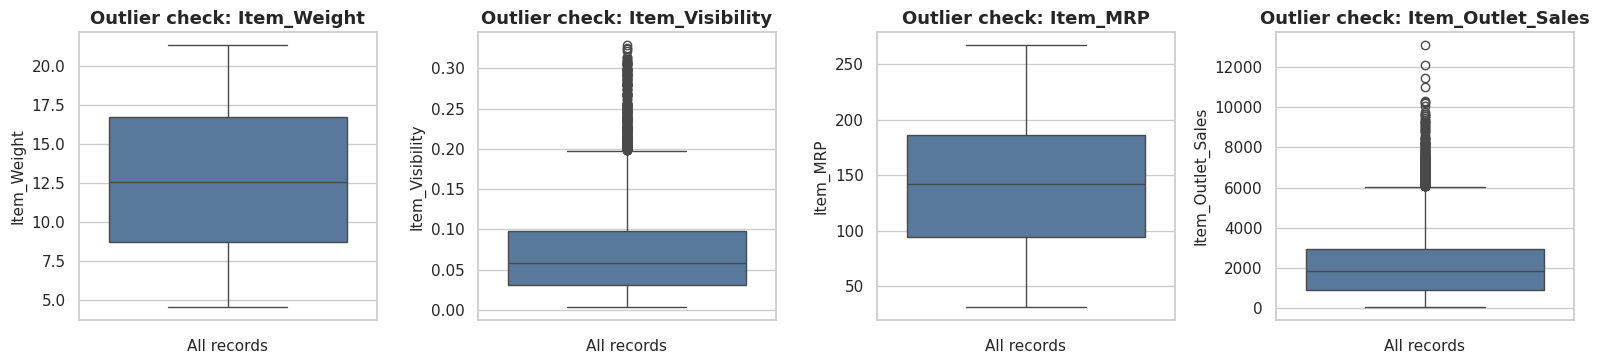

df_clean ready: (14204, 16)


In [59]:
num_check = ["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Outlet_Sales"]
rows = []
for c in num_check:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    rows.append({"column": c, "lower_fence": lo, "upper_fence": hi, "n_outliers": n_out,
                 "pct_outliers": round(n_out / len(df) * 100, 2), "skewness": df[c].skew()})
outlier_table = pd.DataFrame(rows).set_index("column")
display(outlier_table)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, c in zip(axes, num_check):
    sns.boxplot(y=df[c], ax=ax, color="#4C78A8")
    ax.set_title(f"Outlier check: {c}")
    ax.set_ylabel(c)
    ax.set_xlabel("All records")
plt.tight_layout(); plt.show()
df_clean = df.copy()
print("df_clean ready:", df_clean.shape)

## 6. Exploratory Data Analysis (EDA)

The dataset has **no transaction or customer identifiers and no quantity column**, so transactions, quantity sold, average transaction value and unique customers cannot be computed. The KPIs below use what exists: total sales, item–outlet records, unique items and outlets.

In [60]:
total_sales = df_clean["Item_Outlet_Sales"].sum()
kpis = pd.Series({
    "Total sales (dataset currency units)": total_sales,
    "Item-outlet records (rows)": len(df_clean),
    "Unique items": df_clean["Item_Identifier"].nunique(),
    "Unique outlets": df_clean["Outlet_Identifier"].nunique(),
    "Mean sales per item-outlet record": df_clean["Item_Outlet_Sales"].mean(),
    "Median sales per item-outlet record": df_clean["Item_Outlet_Sales"].median(),
    "Max sales of a single record": df_clean["Item_Outlet_Sales"].max(),
})
display(kpis.to_frame("value"))
wanted = {"transactions": ("transaction", "invoice", "order"), "quantity": ("quantity", "qty", "units"),
          "customers": ("customer", "cust_id", "client"), "age": ("age",), "gender": ("gender", "sex")}
for what, keys in wanted.items():
    found = [c for c in df_clean.columns if any(k in c.lower() for k in keys)]
    print(f"{what:<13}: {'found -> ' + str(found) if found else 'NOT available in this dataset'}")

,value
Total sales (dataset currency units),"29,818,933.452"
Item-outlet records (rows),"14,204.000"
Unique items,"1,559.000"
Unique outlets,10.000
Mean sales per item-outlet record,"2,099.334"
Median sales per item-outlet record,"1,828.273"
Max sales of a single record,"13,086.965"


transactions : NOT available in this dataset
quantity     : NOT available in this dataset
customers    : NOT available in this dataset
age          : NOT available in this dataset
gender       : NOT available in this dataset


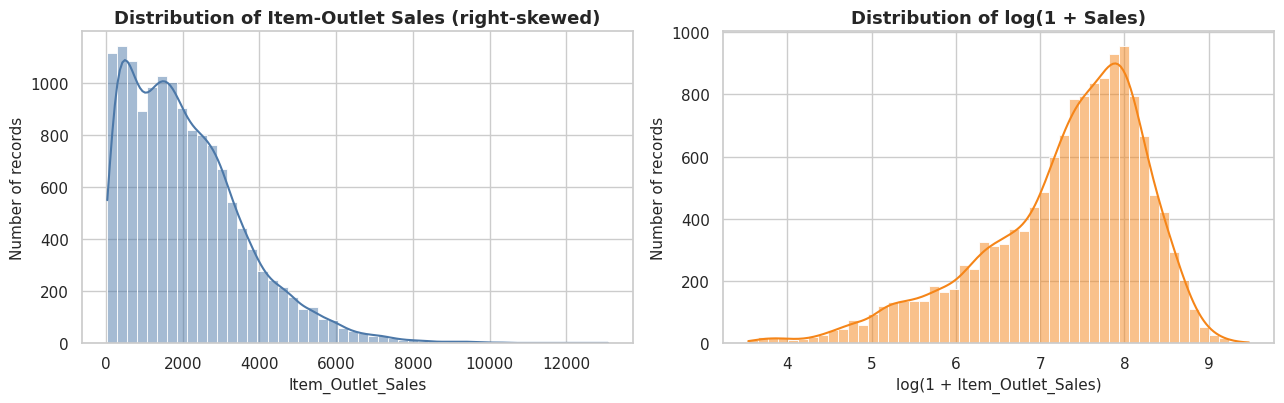

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(df_clean["Item_Outlet_Sales"], bins=50, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribution of Item-Outlet Sales (right-skewed)")
axes[0].set_xlabel("Item_Outlet_Sales"); axes[0].set_ylabel("Number of records")
sns.histplot(np.log1p(df_clean["Item_Outlet_Sales"]), bins=50, kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("Distribution of log(1 + Sales)")
axes[1].set_xlabel("log(1 + Item_Outlet_Sales)"); axes[1].set_ylabel("Number of records")
plt.tight_layout(); plt.show()

,total_sales,mean_sales_per_record,records,share_of_total_%
Item_Type,,,,
Fruits and Vegetables,"4,388,855.958","2,180.256",2013,14.718
Snack Foods,"4,349,839.562","2,186.948",1989,14.588
Household,"3,375,888.396","2,180.806",1548,11.321
Frozen Foods,"2,853,719.307","2,001.206",1426,9.570
Dairy,"2,438,365.449","2,146.448",1136,8.177
Canned,"2,293,210.078","2,115.507",1084,7.690
Baking Goods,"2,059,889.877","1,896.768",1086,6.908
Health and Hygiene,"1,703,294.755","1,985.192",858,5.712
Meat,"1,552,021.161","2,108.724",736,5.205


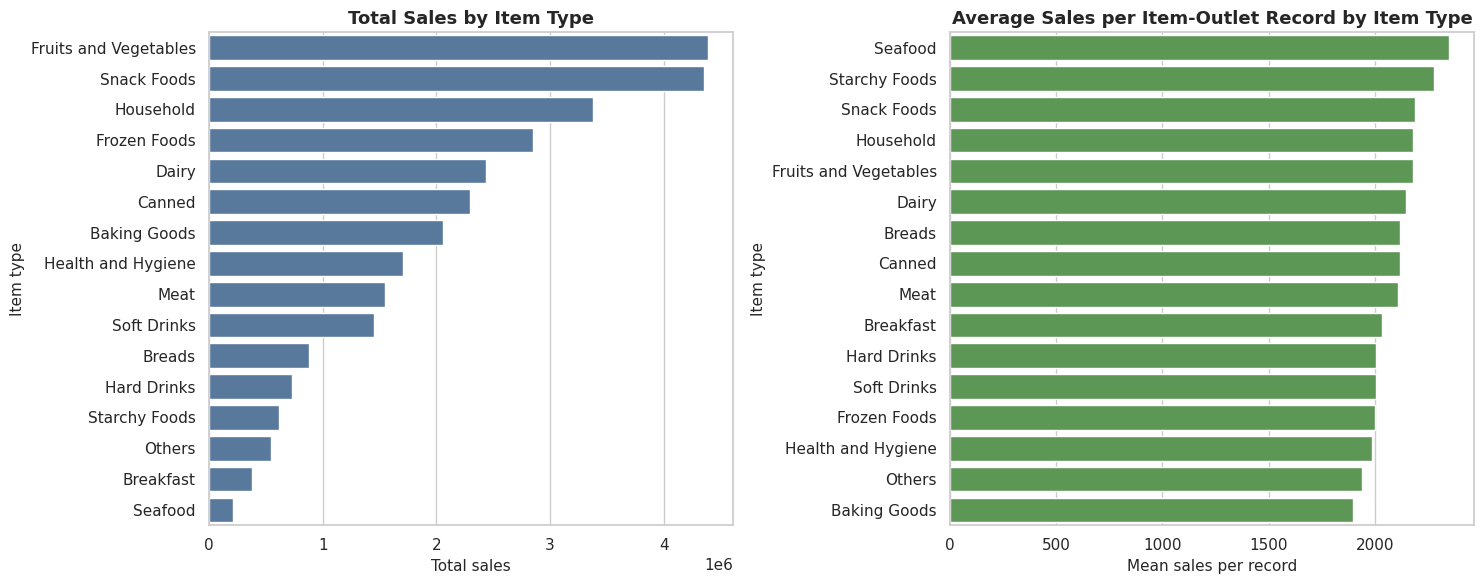

In [62]:

type_perf = (df_clean.groupby("Item_Type")["Item_Outlet_Sales"]
             .agg(total_sales="sum", mean_sales_per_record="mean", records="count")
             .sort_values("total_sales", ascending=False))
type_perf["share_of_total_%"] = type_perf["total_sales"] / total_sales * 100
display(type_perf)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=type_perf["total_sales"], y=type_perf.index, ax=axes[0], color="#4C78A8")
axes[0].set_title("Total Sales by Item Type"); axes[0].set_xlabel("Total sales"); axes[0].set_ylabel("Item type")
order = type_perf.sort_values("mean_sales_per_record", ascending=False).index
sns.barplot(x=type_perf.loc[order, "mean_sales_per_record"], y=order, ax=axes[1], color="#54A24B")
axes[1].set_title("Average Sales per Item-Outlet Record by Item Type")
axes[1].set_xlabel("Mean sales per record"); axes[1].set_ylabel("Item type")
plt.tight_layout(); plt.show()

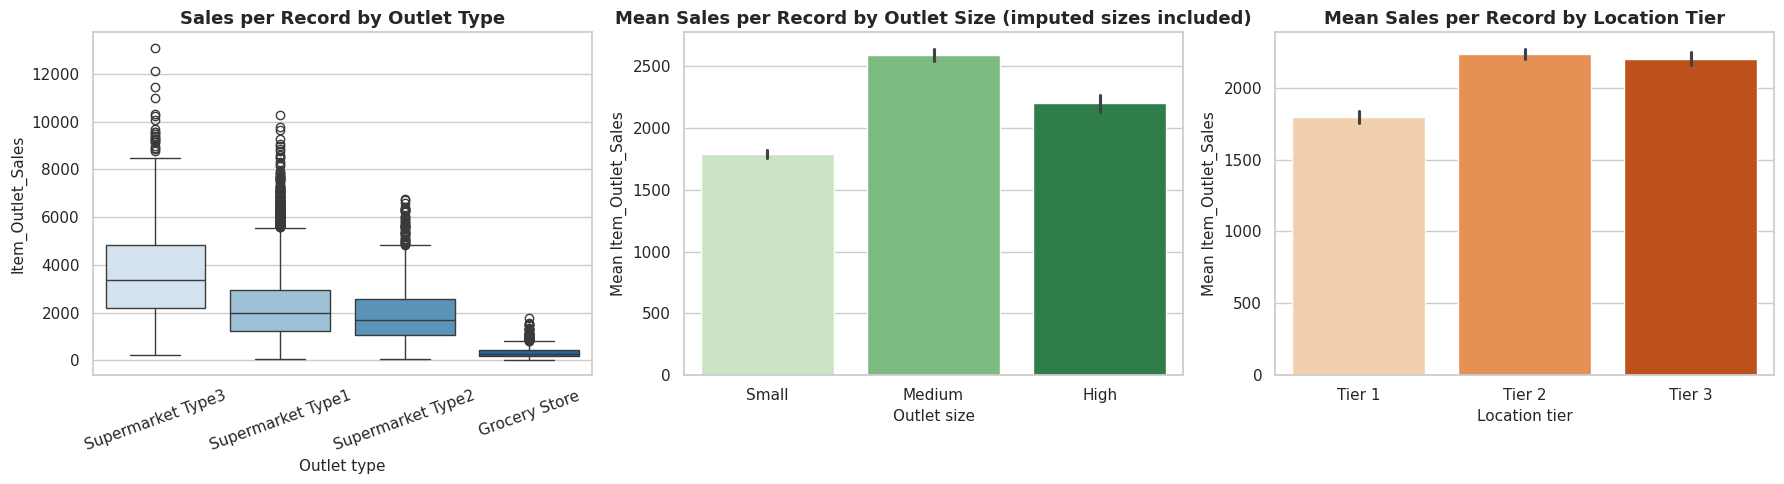

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
order_t = df_clean.groupby("Outlet_Type")["Item_Outlet_Sales"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="Outlet_Type", y="Item_Outlet_Sales", order=order_t, ax=axes[0], palette="Blues")
axes[0].set_title("Sales per Record by Outlet Type"); axes[0].set_xlabel("Outlet type"); axes[0].set_ylabel("Item_Outlet_Sales")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=df_clean, x="Outlet_Size", y="Item_Outlet_Sales", order=["Small", "Medium", "High"],
            ax=axes[1], palette="Greens", errorbar="ci")
axes[1].set_title("Mean Sales per Record by Outlet Size (imputed sizes included)")
axes[1].set_xlabel("Outlet size"); axes[1].set_ylabel("Mean Item_Outlet_Sales")

sns.barplot(data=df_clean, x="Outlet_Location_Type", y="Item_Outlet_Sales", order=["Tier 1", "Tier 2", "Tier 3"],
            ax=axes[2], palette="Oranges", errorbar="ci")
axes[2].set_title("Mean Sales per Record by Location Tier")
axes[2].set_xlabel("Location tier"); axes[2].set_ylabel("Mean Item_Outlet_Sales")
plt.tight_layout(); plt.show()

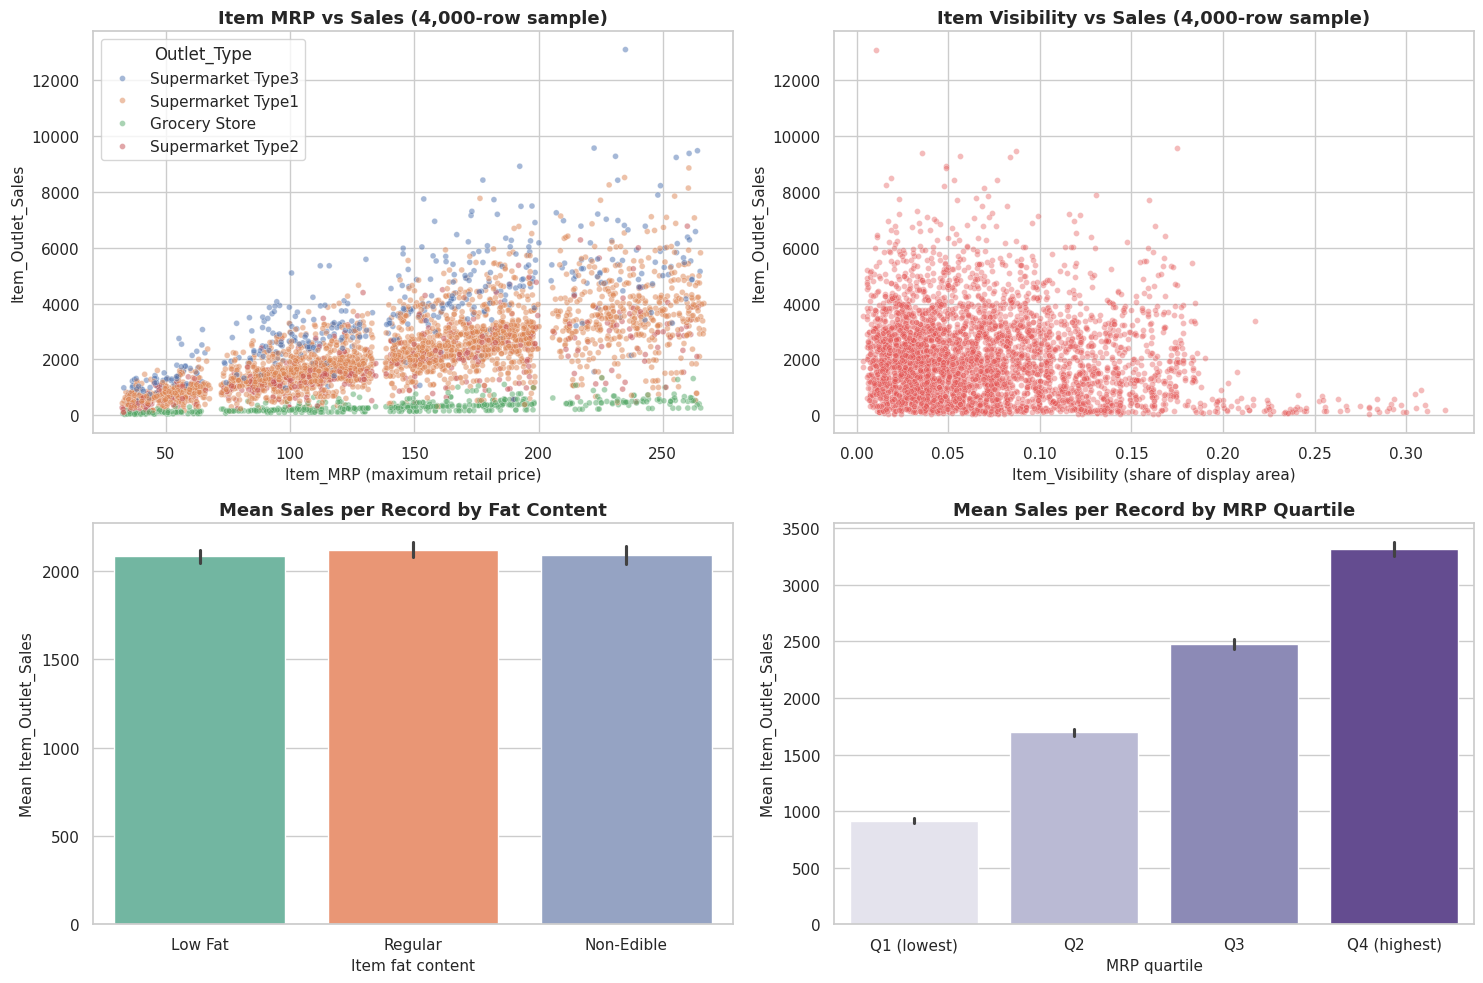

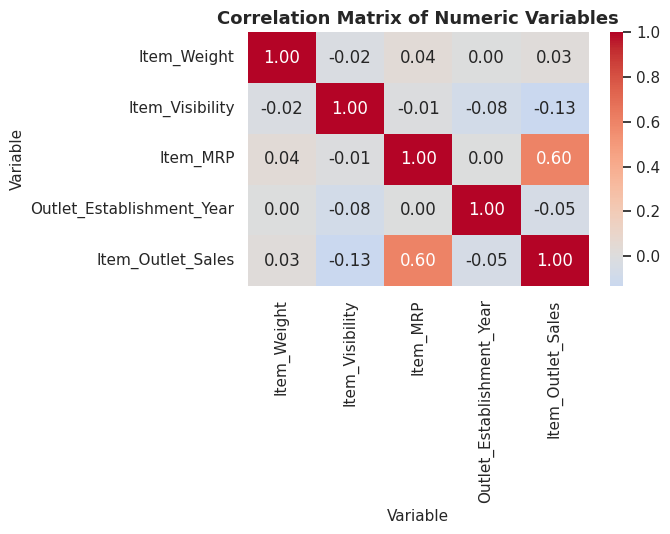

Correlation between Item_MRP and Item_Outlet_Sales: 0.60


In [64]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
samp = df_clean.sample(4000, random_state=RANDOM_STATE)
sns.scatterplot(data=samp, x="Item_MRP", y="Item_Outlet_Sales", hue="Outlet_Type", alpha=0.5, s=18, ax=axes[0, 0])
axes[0, 0].set_title("Item MRP vs Sales (4,000-row sample)")
axes[0, 0].set_xlabel("Item_MRP (maximum retail price)"); axes[0, 0].set_ylabel("Item_Outlet_Sales")

sns.scatterplot(data=samp, x="Item_Visibility", y="Item_Outlet_Sales", alpha=0.4, s=18, ax=axes[0, 1], color="#E45756")
axes[0, 1].set_title("Item Visibility vs Sales (4,000-row sample)")
axes[0, 1].set_xlabel("Item_Visibility (share of display area)"); axes[0, 1].set_ylabel("Item_Outlet_Sales")

sns.barplot(data=df_clean, x="Item_Fat_Content", y="Item_Outlet_Sales", ax=axes[1, 0], palette="Set2", errorbar="ci")
axes[1, 0].set_title("Mean Sales per Record by Fat Content")
axes[1, 0].set_xlabel("Item fat content"); axes[1, 0].set_ylabel("Mean Item_Outlet_Sales")

df_clean["MRP_Band"] = pd.qcut(df_clean["Item_MRP"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
sns.barplot(data=df_clean, x="MRP_Band", y="Item_Outlet_Sales", ax=axes[1, 1], palette="Purples", errorbar="ci")
axes[1, 1].set_title("Mean Sales per Record by MRP Quartile")
axes[1, 1].set_xlabel("MRP quartile"); axes[1, 1].set_ylabel("Mean Item_Outlet_Sales")
plt.tight_layout(); plt.show()

num_cols_eda = ["Item_Weight", "Item_Visibility", "Item_MRP", "Outlet_Establishment_Year", "Item_Outlet_Sales"]
plt.figure(figsize=(7, 5.5))
sns.heatmap(df_clean[num_cols_eda].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Variables"); plt.xlabel("Variable"); plt.ylabel("Variable")
plt.tight_layout(); plt.show()
corr_mrp = df_clean["Item_MRP"].corr(df_clean["Item_Outlet_Sales"])
print(f"Correlation between Item_MRP and Item_Outlet_Sales: {corr_mrp:.2f}")

## 7. Customer Analysis

Customer spending behaviour, repeat vs one-time customers, demographics and top customers all require a customer identifier, which this dataset does not contain. Those analyses are therefore **not performed**.

The closest meaningful substitute is an **outlet-level analysis** (where sales are generated).

Customer-level columns found: none -> customer analysis skipped


,Outlet_Identifier,Outlet_Type,Outlet_Size,Outlet_Location_Type,Outlet_Establishment_Year,total_sales,mean_sales_per_record,distinct_items,share_of_total_%
0,OUT027,Supermarket Type3,Medium,Tier 3,1985,"5,605,149.932","3,595.350",1559,18.797
1,OUT035,Supermarket Type1,Small,Tier 2,2004,"3,607,244.689","2,327.255",1550,12.097
2,OUT017,Supermarket Type1,Small,Tier 2,2007,"3,517,541.404","2,279.677",1543,11.796
3,OUT049,Supermarket Type1,Medium,Tier 1,1999,"3,495,627.929","2,255.244",1550,11.723
4,OUT013,Supermarket Type1,High,Tier 3,1987,"3,418,605.834","2,201.292",1553,11.465
5,OUT046,Supermarket Type1,Small,Tier 1,1997,"3,370,809.031","2,174.716",1550,11.304
6,OUT045,Supermarket Type1,Small,Tier 2,2002,"3,242,040.648","2,094.342",1548,10.872
7,OUT018,Supermarket Type2,Medium,Tier 3,2009,"2,979,587.358","1,927.288",1546,9.992
8,OUT010,Grocery Store,Small,Tier 3,1998,"299,023.932",323.269,925,1.003
9,OUT019,Grocery Store,Small,Tier 1,1985,"283,302.696",321.935,880,0.950


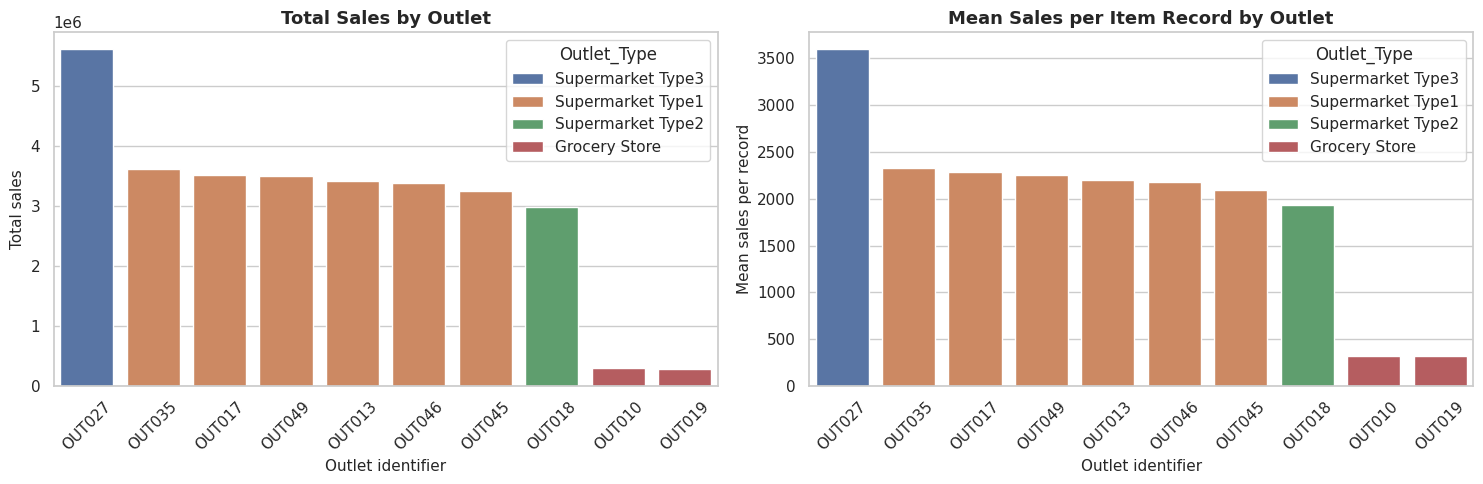

In [65]:
customer_cols = [c for c in df_clean.columns if any(k in c.lower() for k in ("customer", "cust_id", "client", "age", "gender"))]
print("Customer-level columns found:", customer_cols if customer_cols else "none -> customer analysis skipped")

outlet_summary = (df_clean.groupby(["Outlet_Identifier", "Outlet_Type", "Outlet_Size", "Outlet_Location_Type",
                                    "Outlet_Establishment_Year"])["Item_Outlet_Sales"]
                  .agg(total_sales="sum", mean_sales_per_record="mean", distinct_items="nunique")
                  .reset_index().sort_values("total_sales", ascending=False))
# nunique above counts distinct sales values; use item count instead
outlet_summary["distinct_items"] = outlet_summary["Outlet_Identifier"].map(
    df_clean.groupby("Outlet_Identifier")["Item_Identifier"].nunique())
outlet_summary["share_of_total_%"] = outlet_summary["total_sales"] / total_sales * 100
display(outlet_summary.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=outlet_summary, x="Outlet_Identifier", y="total_sales", hue="Outlet_Type", dodge=False, ax=axes[0])
axes[0].set_title("Total Sales by Outlet"); axes[0].set_xlabel("Outlet identifier"); axes[0].set_ylabel("Total sales")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=outlet_summary.sort_values("mean_sales_per_record", ascending=False),
            x="Outlet_Identifier", y="mean_sales_per_record", hue="Outlet_Type", dodge=False, ax=axes[1])
axes[1].set_title("Mean Sales per Item Record by Outlet"); axes[1].set_xlabel("Outlet identifier")
axes[1].set_ylabel("Mean sales per record"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 8. RFM Segmentation

RFM needs, per customer, the **date of last purchase (Recency)**, **number of purchases (Frequency)** and **total spend (Monetary)**. This dataset has no customer ID and no purchase date, so **RFM cannot be calculated and segments are not forced**.

**Alternative supported by the data – product ABC segmentation:** items are ranked by total sales and grouped by cumulative contribution (A ≈ first 70 % of sales, B ≈ next 20 %, C ≈ last 10 %). This is the product-level analogue of "high-value vs low-value" segmentation.

customer id   : NOT available
purchase date : NOT available
amount        : ['Item_Outlet_Sales']

-> RFM requires customer id AND purchase date; not satisfied, so RFM is skipped.



,items,total_sales,share_of_items_%,share_of_sales_%
ABC_class,,,,
A,788,"20,880,425.884",50.545,70.024
B,395,"5,965,361.284",25.337,20.005
C,376,"2,973,146.285",24.118,9.971


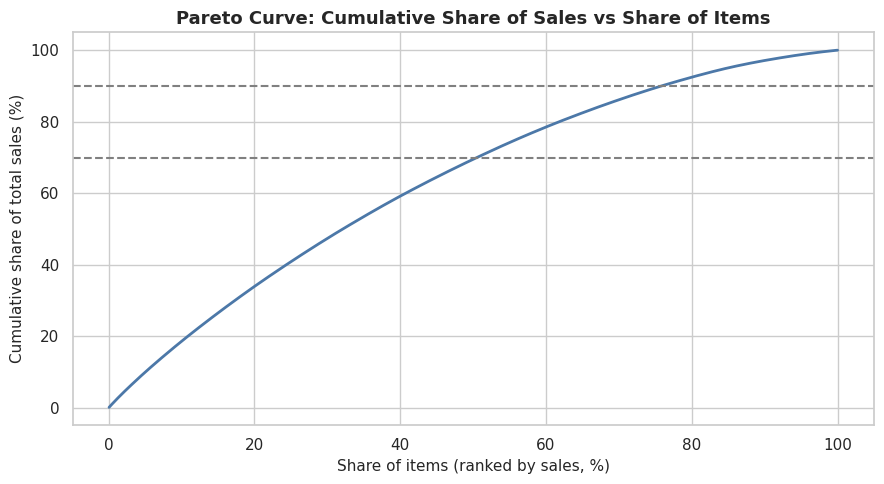

Top 10 items by total sales:


,item_type,total_sales,outlets_sold_in,ABC_class
Item_Identifier,,,,
FDY55,Fruits and Vegetables,"46,933.228",9,A
FDA15,Dairy,"45,388.182",9,A
FDK03,Dairy,"43,306.382",9,A
FDZ20,Fruits and Vegetables,"42,978.848",10,A
FDU55,Fruits and Vegetables,"42,937.814",8,A
FDD44,Fruits and Vegetables,"42,339.080",8,A
FDP15,Meat,"41,622.475",10,A
FDF39,Dairy,"41,605.033",9,A
NCV53,Health and Hygiene,"41,487.313",9,A


In [66]:
rfm_needed = {"customer id": ("customer", "cust_id"), "purchase date": ("date", "time"), "amount": ("amount", "sales")}
for need, keys in rfm_needed.items():
    found = [c for c in df_clean.columns if any(k in c.lower() for k in keys)]
    print(f"{need:<14}: {found if found else 'NOT available'}")
print("\n-> RFM requires customer id AND purchase date; not satisfied, so RFM is skipped.\n")


item_sales = (df_clean.groupby("Item_Identifier")
              .agg(total_sales=("Item_Outlet_Sales", "sum"),
                   outlets_sold_in=("Outlet_Identifier", "nunique"),
                   item_type=("Item_Type", "first"))
              .sort_values("total_sales", ascending=False))
item_sales["cum_share_%"] = item_sales["total_sales"].cumsum() / item_sales["total_sales"].sum() * 100

prev_cum = item_sales["cum_share_%"] - item_sales["total_sales"] / item_sales["total_sales"].sum() * 100
item_sales["ABC_class"] = np.select([prev_cum < 70, prev_cum < 90], ["A", "B"], default="C")

abc_summary = item_sales.groupby("ABC_class").agg(items=("total_sales", "size"), total_sales=("total_sales", "sum"))
abc_summary["share_of_items_%"] = abc_summary["items"] / len(item_sales) * 100
abc_summary["share_of_sales_%"] = abc_summary["total_sales"] / item_sales["total_sales"].sum() * 100
display(abc_summary)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(item_sales) + 1) / len(item_sales) * 100, item_sales["cum_share_%"], color="#4C78A8", lw=2)
ax.axhline(70, ls="--", color="grey"); ax.axhline(90, ls="--", color="grey")
ax.set_title("Pareto Curve: Cumulative Share of Sales vs Share of Items")
ax.set_xlabel("Share of items (ranked by sales, %)"); ax.set_ylabel("Cumulative share of total sales (%)")
plt.tight_layout(); plt.show()

print("Top 10 items by total sales:")
display(item_sales.head(10)[["item_type", "total_sales", "outlets_sold_in", "ABC_class"]])

## 9. Feature Engineering

Requested features such as recency, frequency, monetary value, average order value, categories purchased and age groups are customer-level and **cannot be built** from this data. The following **row-level features that exist at prediction time** are used instead:

* `Price_per_Weight` = `Item_MRP / Item_Weight` (price intensity of the product)
* `Item_Category` (Food / Drinks / Non-Consumable, derived from the item ID prefix)
* `Outlet_Establishment_Year` (outlet age proxy; the dataset has no sales dates, so no calendar features exist)
* the cleaned item and outlet attributes

**Leakage control**
* `Item_Outlet_Sales` (the target) is never used to build any feature.
* `Item_Identifier` is **not** a feature (1,559 levels would let the model memorise items); `Outlet_Identifier` is not used either, because it only duplicates the outlet attributes already included.
* The imputation flags are not used as features.
* The train/test split is made first; scaling and one-hot encoding are fitted **only on the training data** inside a scikit-learn `Pipeline`.

In [67]:
df_clean["Price_per_Weight"] = df_clean["Item_MRP"] / df_clean["Item_Weight"]

TARGET = "Item_Outlet_Sales"
num_features = ["Item_Weight", "Item_Visibility", "Item_MRP", "Price_per_Weight", "Outlet_Establishment_Year"]
cat_features = ["Item_Fat_Content", "Item_Type", "Item_Category", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]

X = df_clean[num_features + cat_features]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
groups_all = df_clean["Item_Identifier"]
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("Features used:", num_features + cat_features)

Train: (11363, 11)   Test: (2841, 11)
Features used: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Price_per_Weight', 'Outlet_Establishment_Year', 'Item_Fat_Content', 'Item_Type', 'Item_Category', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


## 10. Predictive Modeling

**Problem type: regression** – predict `Item_Outlet_Sales` for an item at an outlet.

Models:
1. **Baseline** – predicts the training mean (any useful model must beat it).
2. **Linear Regression** – interpretable benchmark (numeric features standardised, categoricals one-hot encoded).
3. **Random Forest Regressor** – non-linear model; hyper-parameters are tuned with 5-fold cross-validation **on the training set only**.

The best model is selected by **cross-validated RMSE on the training data**; the test set is used only once, for the final report.

In [68]:
def make_preprocessor(scale_numeric):
    num_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer([("num", num_step, num_features),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Baseline (mean)":   Pipeline([("prep", make_preprocessor(False)), ("model", DummyRegressor(strategy="mean"))]),
    "Linear Regression": Pipeline([("prep", make_preprocessor(True)),  ("model", LinearRegression())]),
}


rf_pipe = Pipeline([("prep", make_preprocessor(False)),
                    ("model", RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE))])
param_grid = {"model__max_depth": [6, 10],
              "model__min_samples_leaf": [10, 30, 60]}
grid = GridSearchCV(rf_pipe, param_grid, cv=cv, scoring="neg_root_mean_squared_error")
grid.fit(X_train, y_train)
print("Best Random Forest parameters:", grid.best_params_)
models["Random Forest"] = grid.best_estimator_

for name in ["Baseline (mean)", "Linear Regression"]:
    models[name].fit(X_train, y_train)

Best Random Forest parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 30}


## 11. Model Evaluation

In [69]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

results, preds = [], {}
for name, mdl in models.items():
    cv_rmse = -cross_val_score(mdl, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")
    p = mdl.predict(X_test); preds[name] = p
    results.append({"Model": name,
                    "CV RMSE (train, 5-fold)": cv_rmse.mean(),
                    "Test MAE": mean_absolute_error(y_test, p),
                    "Test RMSE": rmse(y_test, p),
                    "Test R2": r2_score(y_test, p)})
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.round(3))

best_name = results_df["CV RMSE (train, 5-fold)"].idxmin()
best_model = models[best_name]
print(f"\nBest model by cross-validated RMSE: {best_name}")

,"CV RMSE (train, 5-fold)",Test MAE,Test RMSE,Test R2
Model,,,,
Baseline (mean),"1,553.354","1,194.201","1,497.586",-0.001
Linear Regression,934.065,612.901,888.717,0.647
Random Forest,871.430,523.804,824.844,0.696



Best model by cross-validated RMSE: Random Forest


In [70]:

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X, y, groups=groups_all))
Xg_tr, Xg_te, yg_tr, yg_te = X.iloc[tr_idx], X.iloc[te_idx], y.iloc[tr_idx], y.iloc[te_idx]

from sklearn.base import clone
group_rows = []
for name, mdl in models.items():
    m = clone(mdl).fit(Xg_tr, yg_tr)
    p = m.predict(Xg_te)
    group_rows.append({"Model": name, "MAE": mean_absolute_error(yg_te, p),
                       "RMSE": rmse(yg_te, p), "R2": r2_score(yg_te, p)})
print("Performance when test items are completely unseen during training:")
display(pd.DataFrame(group_rows).set_index("Model").round(3))

Performance when test items are completely unseen during training:


,MAE,RMSE,R2
Model,,,
Baseline (mean),"1,226.885","1,555.320",-0.000
Linear Regression,632.320,935.428,0.638
Random Forest,539.182,873.337,0.685


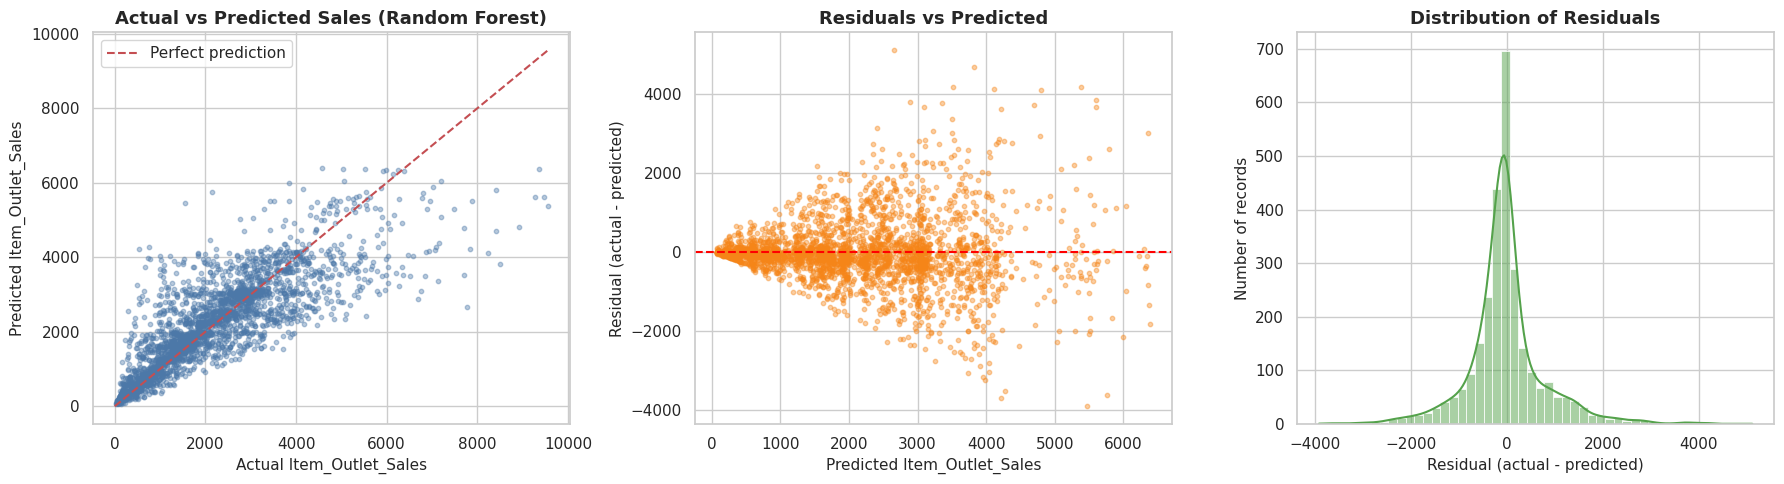

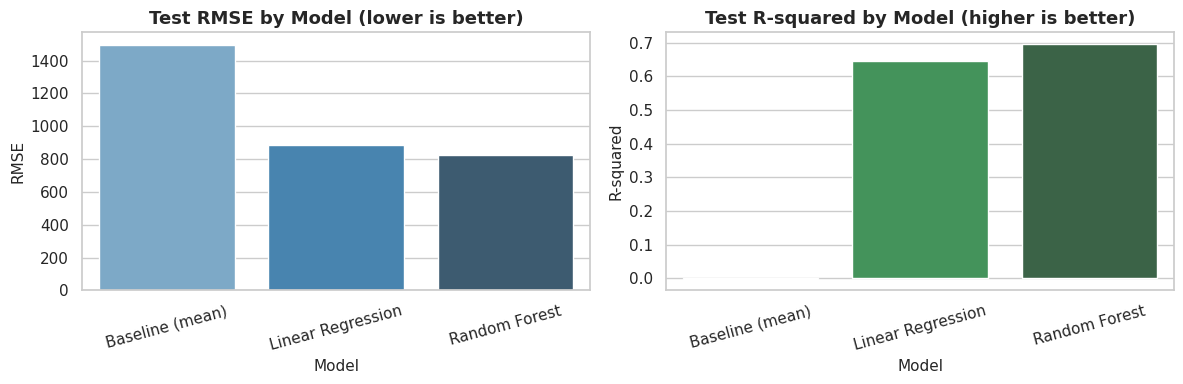

In [71]:

p_best = preds[best_name]
resid = y_test - p_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_test, p_best, s=10, alpha=0.4, color="#4C78A8")
lim = [0, max(y_test.max(), p_best.max())]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_title(f"Actual vs Predicted Sales ({best_name})")
axes[0].set_xlabel("Actual Item_Outlet_Sales"); axes[0].set_ylabel("Predicted Item_Outlet_Sales"); axes[0].legend()

axes[1].scatter(p_best, resid, s=10, alpha=0.4, color="#F58518")
axes[1].axhline(0, color="red", ls="--")
axes[1].set_title("Residuals vs Predicted"); axes[1].set_xlabel("Predicted Item_Outlet_Sales")
axes[1].set_ylabel("Residual (actual - predicted)")

sns.histplot(resid, bins=50, kde=True, ax=axes[2], color="#54A24B")
axes[2].set_title("Distribution of Residuals"); axes[2].set_xlabel("Residual (actual - predicted)")
axes[2].set_ylabel("Number of records")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=results_df.index, y=results_df["Test RMSE"], ax=axes[0], palette="Blues_d")
axes[0].set_title("Test RMSE by Model (lower is better)"); axes[0].set_xlabel("Model"); axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)
sns.barplot(x=results_df.index, y=results_df["Test R2"], ax=axes[1], palette="Greens_d")
axes[1].set_title("Test R-squared by Model (higher is better)"); axes[1].set_xlabel("Model"); axes[1].set_ylabel("R-squared")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 12. Demand Analysis / Prediction

A true demand forecast needs **quantity sold (or sales) recorded over time**. This dataset has **no date column and no quantity column**; each item outlet pair appears exactly once. Therefore:

* **Time-series trend analysis and a time-based train/test forecast are not possible and are not attempted.** No seasonality or forecast is claimed.
* `Outlet_Establishment_Year` is when an outlet opened, not when sales occurred, so it cannot serve as a time axis for demand.

What the data *does* support is **cross-sectional demand analysis**: how sales (the only demand proxy available) differ across product categories and outlet types, and what the regression model in Section 10 predicts for item–outlet combinations.

Date-like columns: none
Records per (item, outlet) pair - max: 1


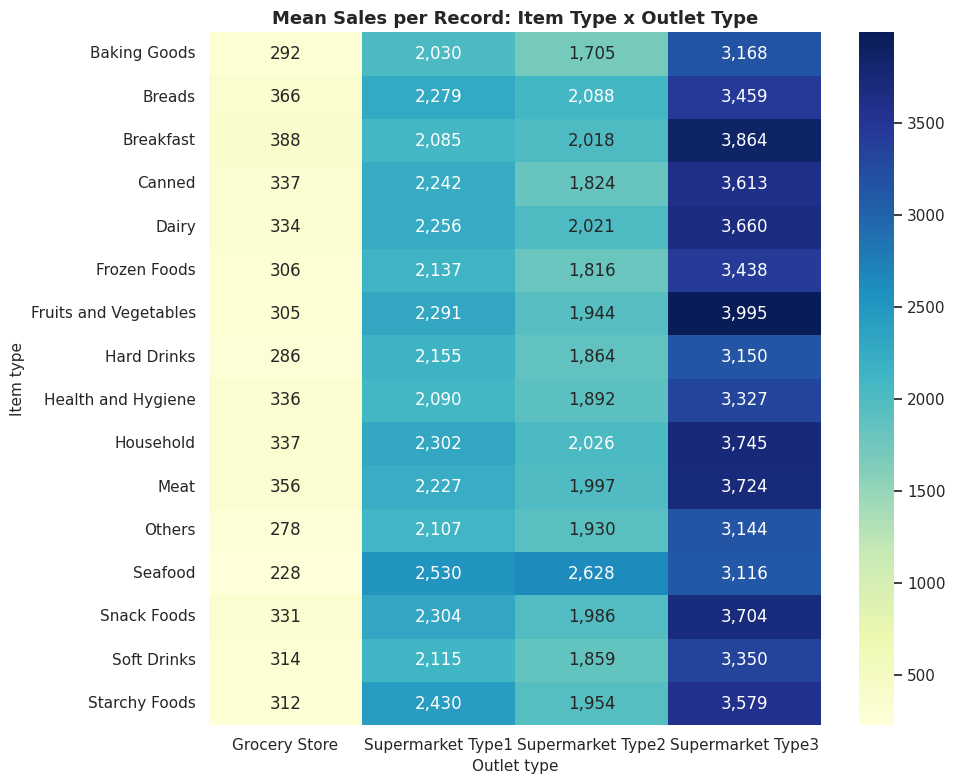

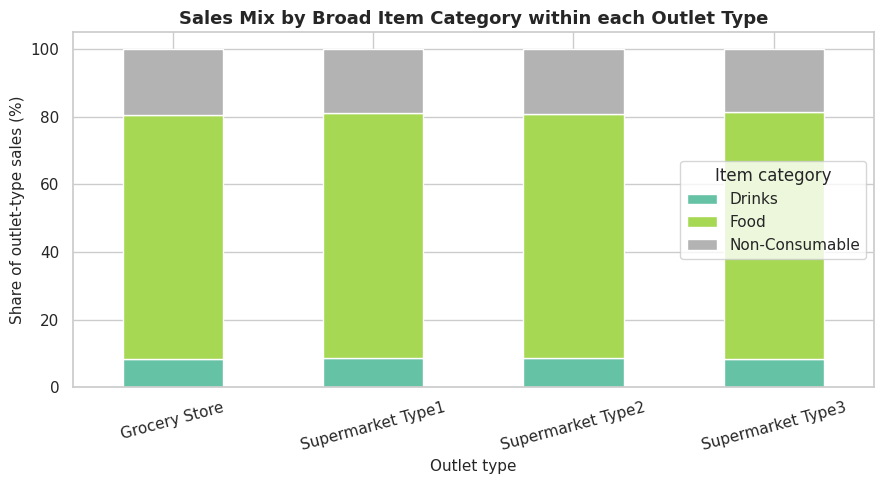

In [72]:

print("Date-like columns:", [c for c in df_clean.columns if pd.api.types.is_datetime64_any_dtype(df_clean[c])] or "none")
print("Records per (item, outlet) pair - max:", df_clean.groupby(["Item_Identifier", "Outlet_Identifier"]).size().max())

pivot_mean = df_clean.pivot_table(index="Item_Type", columns="Outlet_Type", values="Item_Outlet_Sales", aggfunc="mean")
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_mean, annot=True, fmt=",.0f", cmap="YlGnBu")
plt.title("Mean Sales per Record: Item Type x Outlet Type")
plt.xlabel("Outlet type"); plt.ylabel("Item type")
plt.tight_layout(); plt.show()

share = df_clean.pivot_table(index="Outlet_Type", columns="Item_Category", values="Item_Outlet_Sales", aggfunc="sum")
share = share.div(share.sum(axis=1), axis=0) * 100
ax = share.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
ax.set_title("Sales Mix by Broad Item Category within each Outlet Type")
ax.set_xlabel("Outlet type"); ax.set_ylabel("Share of outlet-type sales (%)")
plt.xticks(rotation=15); plt.legend(title="Item category"); plt.tight_layout(); plt.show()

,actual,predicted,abs_error_%
Item_Type,,,
Hard Drinks,"2,332.900","2,265.600",2.900
Breads,"2,276.100","2,100.800",7.700
Starchy Foods,"2,255.500","2,238.100",0.800
Seafood,"2,218.000","2,031.700",8.400
Snack Foods,"2,180.600","2,176.300",0.200
Meat,"2,137.000","2,094.100",2.000
Fruits and Vegetables,"2,090.100","2,138.600",2.300
Soft Drinks,"2,084.300","2,086.900",0.100
Dairy,"2,055.300","2,221.100",8.100


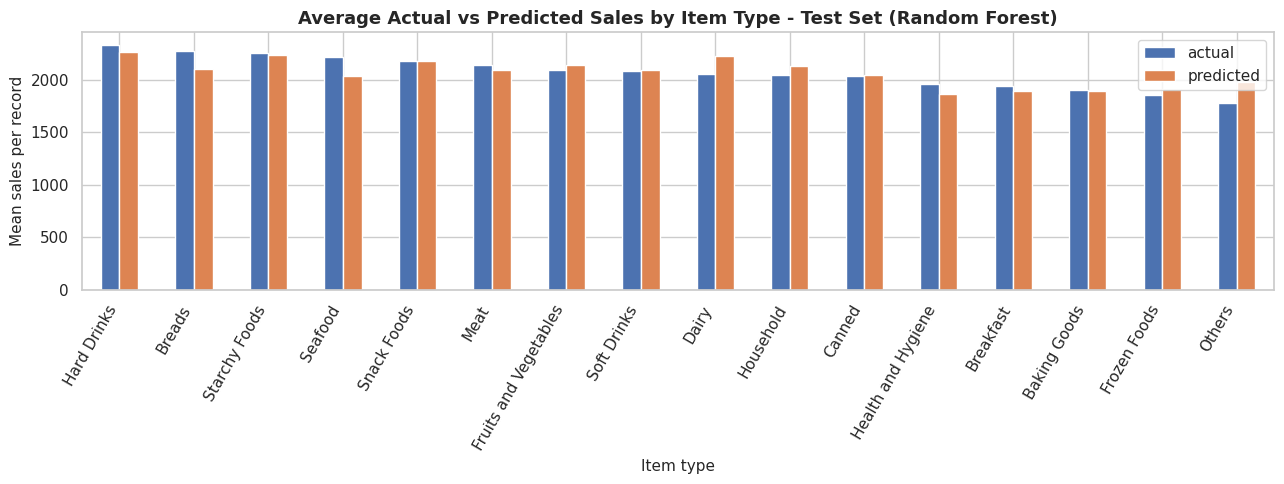

In [73]:
check = X_test.copy()
check["actual"] = y_test.values
check["predicted"] = preds[best_name]
by_type = check.groupby("Item_Type")[["actual", "predicted"]].mean().sort_values("actual", ascending=False)
by_type["abs_error_%"] = (by_type["predicted"] - by_type["actual"]).abs() / by_type["actual"] * 100
display(by_type.round(1))

by_type[["actual", "predicted"]].plot(kind="bar", figsize=(13, 5))
plt.title(f"Average Actual vs Predicted Sales by Item Type - Test Set ({best_name})")
plt.xlabel("Item type"); plt.ylabel("Mean sales per record")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

## 13. Feature Importance

Feature importance is shown for the **Random Forest** (the tree-based model) in two ways:
* **Impurity-based importance** (built into the forest), summed back to the original variable so one-hot columns are not shown separately.
* **Permutation importance** on the hold-out test set (how much R² drops when a variable is shuffled) – less biased towards high-cardinality features.

These indicate which variables are **associated with** sales predictions; they do not establish causation.

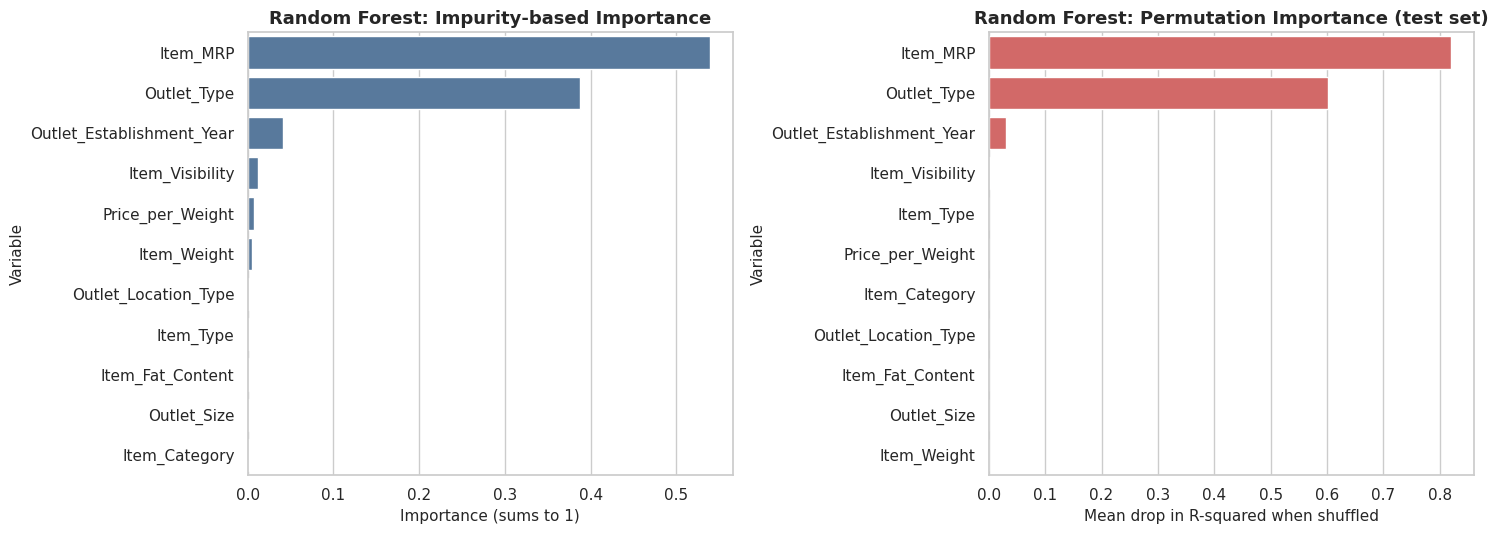

,impurity_importance,permutation_importance
Item_MRP,0.539,0.820
Outlet_Type,0.388,0.602
Outlet_Establishment_Year,0.042,0.030
Item_Visibility,0.012,0.003
Item_Type,0.002,0.001
Price_per_Weight,0.007,0.001
Item_Category,0.001,0.001
Outlet_Location_Type,0.002,0.000
Item_Fat_Content,0.002,0.000
Outlet_Size,0.001,0.000


Interpretation (associations only, not causation):
* The variables most associated with predicted sales are: Item_MRP, Outlet_Type, Outlet_Establishment_Year.
* Outlet_Establishment_Year takes only 9 distinct values across the 10 outlets, so it may be acting as a stand-in for outlet identity rather than outlet age.
* Variables with near-zero permutation importance add little predictive information once the others are known.


In [74]:
rf_pipe_fitted = models["Random Forest"]
prep = rf_pipe_fitted.named_steps["prep"]
rf = rf_pipe_fitted.named_steps["model"]

names = prep.get_feature_names_out()
imp = pd.Series(rf.feature_importances_, index=names)
def source_var(n):
    n = n.split("__", 1)[1]
    for f in sorted(num_features + cat_features, key=len, reverse=True):
        if n == f or n.startswith(f + "_"):
            return f
    return n
imp_grouped = imp.groupby(source_var).sum().sort_values(ascending=False)

perm = permutation_importance(rf_pipe_fitted, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
                              scoring="r2")
perm_s = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(x=imp_grouped.values, y=imp_grouped.index, ax=axes[0], color="#4C78A8")
axes[0].set_title("Random Forest: Impurity-based Importance"); axes[0].set_xlabel("Importance (sums to 1)"); axes[0].set_ylabel("Variable")
sns.barplot(x=perm_s.values, y=perm_s.index, ax=axes[1], color="#E45756")
axes[1].set_title("Random Forest: Permutation Importance (test set)"); axes[1].set_xlabel("Mean drop in R-squared when shuffled"); axes[1].set_ylabel("Variable")
plt.tight_layout(); plt.show()

fi_table = pd.DataFrame({"impurity_importance": imp_grouped, "permutation_importance": perm_s}).sort_values("permutation_importance", ascending=False)
display(fi_table.round(4))

top3 = list(perm_s.index[:3])
print("Interpretation (associations only, not causation):")
print(f"* The variables most associated with predicted sales are: {', '.join(top3)}.")
print("* Outlet_Establishment_Year takes only 9 distinct values across the 10 outlets, so it may be acting as a stand-in for outlet identity rather than outlet age.")
print("* Variables with near-zero permutation importance add little predictive information once the others are known.")

## 14. Business Insights


In [75]:
top_type = type_perf.index[0]
top_type_share = type_perf["share_of_total_%"].iloc[0]
best_mean_type = type_perf["mean_sales_per_record"].idxmax()
top3_types_share = type_perf["share_of_total_%"].head(3).sum()

ot = df_clean.groupby("Outlet_Type")["Item_Outlet_Sales"].agg(["sum", "mean", "count"])
best_ot, worst_ot = ot["mean"].idxmax(), ot["mean"].idxmin()
n_out = df_clean.groupby("Outlet_Type")["Outlet_Identifier"].nunique()
top_outlet = outlet_summary.iloc[0]
a_items = int(abc_summary.loc["A", "items"]); a_item_pct = abc_summary.loc["A", "share_of_items_%"]
a_sales_pct = abc_summary.loc["A", "share_of_sales_%"]

base_r2 = results_df.loc["Baseline (mean)", "Test R2"]
best_r2 = results_df.loc[best_name, "Test R2"]
best_mae = results_df.loc[best_name, "Test MAE"]
best_rmse = results_df.loc[best_name, "Test RMSE"]
lr_r2 = results_df.loc["Linear Regression", "Test R2"]
rf_r2 = results_df.loc["Random Forest", "Test R2"]
zero_vis_pct = raw["Item_Visibility"].eq(0).mean() * 100
size_imp_outlets = ", ".join(size_fill.keys())

print("KEY FINDINGS")
print("-" * 70)
print(f"1. Data scope: {len(df_clean):,} item-outlet records, {df_clean['Item_Identifier'].nunique():,} items, "
      f"{df_clean['Outlet_Identifier'].nunique()} outlets. There are no dates, customers or quantities, so trend, customer/RFM "
      f"and time-based forecasting analyses are not possible with this dataset.")
print(f"2. Total sales are {total_sales:,.0f}. '{top_type}' is the largest item type ({top_type_share:.1f}% of sales); "
      f"the top 3 types together account for {top3_types_share:.1f}%. '{best_mean_type}' has the highest average sales per record, "
      f"but it rests on only {int(type_perf.loc[best_mean_type, 'records'])} records, so treat it cautiously.")
print(f"3. Outlet type matters: '{best_ot}' has the highest mean sales per record ({ot.loc[best_ot, 'mean']:,.0f}) and "
      f"'{worst_ot}' the lowest ({ot.loc[worst_ot, 'mean']:,.0f}). Note '{best_ot}' is only {n_out[best_ot]} outlet(s) and "
      f"'{worst_ot}' is {n_out[worst_ot]}, so this is outlet-level evidence, not proof about the format. The top outlet by total sales is {top_outlet['Outlet_Identifier']} "
      f"({top_outlet['share_of_total_%']:.1f}% of all sales).")
print(f"4. Product concentration: {a_items:,} items ({a_item_pct:.1f}% of items) generate {a_sales_pct:.1f}% of sales (ABC class A).")
print(f"5. Item_MRP has a correlation of {corr_mrp:.2f} with sales, the strongest numeric relationship observed.")
print(f"6. Data quality: {zero_vis_pct:.1f}% of rows had Item_Visibility = 0 (treated as missing); Item_Weight and Outlet_Size were "
      f"missing only for specific outlets (Outlet_Size imputed for {size_imp_outlets}, an assumption).")
print(f"7. Modeling: on the hold-out test set, Linear Regression R2 = {lr_r2:.3f} and Random Forest R2 = {rf_r2:.3f} "
      f"(baseline R2 = {base_r2:.3f}). Best model: {best_name} (MAE {best_mae:,.0f}, RMSE {best_rmse:,.0f}).")
print(f"8. Variables most associated with predicted sales (permutation importance): {', '.join(top3)}.")

print("\nRECOMMENDATIONS (based on the associations above)")
print("-" * 70)
print(f"* Protect availability and pricing review for class-A items and for '{top_type}', which drive the largest share of sales.")
print(f"* Investigate why '{worst_ot}' outlets sell less per item record than '{best_ot}' (range, space, location) before drawing conclusions about the format (only {n_out[best_ot]} '{best_ot}' outlet(s) exist in the data).")
print(f"* Use the {best_name} model as a first-pass planning tool for expected sales of an item at an outlet, "
      f"with the error level above (MAE {best_mae:,.0f}) in mind; it is not a time-based demand forecast.")
print("* Collect transaction dates, quantities and customer IDs. That would enable genuine demand forecasting, "
      "seasonality analysis, RFM segmentation and repeat-customer analysis, none of which this data supports.")
print("* Treat the Outlet_Size imputation and the Item_Visibility = 0 replacement as assumptions; confirm them with the data owner.")

KEY FINDINGS
----------------------------------------------------------------------
1. Data scope: 14,204 item-outlet records, 1,559 items, 10 outlets. There are no dates, customers or quantities, so trend, customer/RFM and time-based forecasting analyses are not possible with this dataset.
2. Total sales are 29,818,933. 'Fruits and Vegetables' is the largest item type (14.7% of sales); the top 3 types together account for 40.6%. 'Seafood' has the highest average sales per record, but it rests on only 89 records, so treat it cautiously.
3. Outlet type matters: 'Supermarket Type3' has the highest mean sales per record (3,595) and 'Grocery Store' the lowest (323). Note 'Supermarket Type3' is only 1 outlet(s) and 'Grocery Store' is 2, so this is outlet-level evidence, not proof about the format. The top outlet by total sales is OUT027 (18.8% of all sales).
4. Product concentration: 788 items (50.5% of items) generate 70.0% of sales (ABC class A).
5. Item_MRP has a correlation of 0.60 with

In [76]:
export_df = df_clean.drop(columns=["MRP_Band"]).copy()
export_df.to_csv("cleaned_retail_sales.csv", index=False)
results_df.round(4).to_csv("model_comparison.csv")
print(f"Saved cleaned_retail_sales.csv ({export_df.shape[0]:,} rows x {export_df.shape[1]} columns) and model_comparison.csv")

try:
    from google.colab import files
    files.download("cleaned_retail_sales.csv")
    files.download("model_comparison.csv")
except ImportError:
    pass

Saved cleaned_retail_sales.csv (14,204 rows x 17 columns) and model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>